## **Проект**: 
## Анализ расхождений оригинальных либретто мюзиклов и их адаптаций на русском языке

#### Структура проекта:

1. Общая подготовка данных
    * импорт из .xlsx
    * первичная предобработка:
        * удаление лишних переносов строк
        * удаление ненужных символов и фрагментов (текст в скобках, информация о количестве повторов строчки и т.д.)
        * замена множественных пробелов на одинарный
        * замена Ё на Е в целях единообразия
    * корректировка корпуса - удаление слишком коротких текстов (менее 10 строчек)

2. Общая оценка схожести оригинальных текстов и переводов на русский с помощью LaBSE
    * инициализация моделей:
        * обычная модель LaBSE "из коробки"
        * модель с явно прописанным пулингом
    * вторая корректировка корпуса - проверка и редакирование пар со слишком большим количеством текста для модели (по токенам)
    * вычислени косинусной близости оригиналов и переводов
    * сравнение значений косинусной близости в разных моделях и с переводом в нижний регистр / без него
    * визуализация результатов
    * обзор кейсов с самымии низкими значениями - сравнение оригинала и перевода по ключевым словам

3. Поиск расхождений в оригинальных либретто и переводах на русский с помощью WordCloud и TF-IDF
    * более широкая предобработка текстов, чем в 1-й части:
        * расширение списка стоп-слов (имена персонажей, специфические неинформативные моменты для определенных текстов, у которых высокая частотность)
        * перевод в нижний регистр, замена всех переносов строк и проч. пробельных символов на обычные пробелы
        * удаление пунктуации
        * токенизация, лемматизация (для русского - pymorphy3, для англйского - spacy)
        * удаление стоп-слов
        * склейка готовых токенов в одну строку
    * удаление повторяющихся строчек в текстах песен
        - предположительно, это улучшит результаты, потому что повторяющиеся для ритма текста, в припевах и т.д. слова будут не так сильно завышаться в плане частотности
    * подготовка корпуса без повторяющихся строк и корпуса в изначальном виде для анализа
    * перевод данных из широкого формата (1 наблюдние = 1 пара перевод-оригинал) в длинный (1 наблюдение = 1 текст на 1 языке)
    * составление облака слов для каждого из вариантов корпусов (для каждого мюзикла - облако оригинала и облак перевода)
    * выделение ключевых слов для оригиналов и переводов мюзиклов в целом


In [70]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# pip install sentence-transformers

In [3]:
from scipy.spatial.distance import cosine

In [71]:
from sentence_transformers import SentenceTransformer, models
import torch

### Импорт данных

In [4]:
p1_songs = pd.read_excel('musdata_edited_final.xlsx')
p2_songs = pd.read_excel('additional_musdata_final.xlsx')

In [5]:
songs = pd.concat([p1_songs, p2_songs], axis = 0, ignore_index=True)
songs.pop('Unnamed: 0')
songs.head(2)

,musical,id,songtitle_eng,songtitle_rus,clean_eng,clean_rus
0,Mamma Mia!,0,"Honey, Honey","МИЛЫЙ, МИЛЫЙ","\nHoney honey, how he thrills me, a-ha, honey ...","Милый, Милый,\nОн волнует меня\nМилый, Милый.\..."
1,Mamma Mia!,1,"Money, Money, Money","ДЕНЬГИ, ДЕНЬГИ, ДЕНЬГИ","\nI work all night, I work all day\nTo pay the...","Работай день, работай ночь, чтоб как-то выкрут..."


In [7]:
# перезапишем столбец с индексами, чтобы нумерация была сквозной
songs['id'] = range(len(songs.songtitle_eng))
songs.tail(2)

,musical,id,songtitle_eng,songtitle_rus,clean_eng,clean_rus
155,Sound of Music,155,Edelweiss,Edelweiss,"\nEdelweiss, Edelweiss\nEvery morning you gree...","\nЭдельвейс, эдельвейс\nЯркий, чистый и нежный..."
156,Sound of Music,156,Climb Ev'ry Mountain (Reprise),Climb Ev'ry Mountain (Reprise),\nA dream that will need\nAll the love you can...,"\nПуть твой за мечтою труден и далёк,\nНо если..."


In [8]:
mustitles = songs['musical'].unique()
print(mustitles)

['Mamma Mia!' 'Chess' 'Jekyll & Hyde' 'Cats' 'Hair'
 'Jesus Christ Superstar' 'Sound of Music']


### Предобработка текстов: общая
При использовании LaBSE тексты должны быть "натуральными" - со всеми стоп-словами, знаками препинания, а в нашем случае еще и с переносами строк (ведь таков формат текстов песен). Однако все равно требуется некоторая предварительная обработка. **Удаляем**:
* несколько переносов строк подряд - замена на одинарный
* переносы строк в самом начале текста (артефакты парсинга)
* символы &, " (артефакты от удаления обозначений поющих/говорящих)
* множесвенные впросительные знаки - несколько раз встречаются и указывают на то, что какое-то слово в тексте не удалось разобрать
* текст в скобках - это технические детали вроде характера звучания/контекста строчки песни: *(with desperation), (подходя к окну), (тише)*; указание на количество повторов строчки *(2 раза), (х5)*; текст, который параллельноо основным партиям поют другие персонажи или хор, в большинстве случаев полностью или частично дублируют основной текс
* множественные пробелы

А также везде заменим "ё" на "е", чтобы тексты на русском были единообразны.

In [9]:
# слегка обработаем тексты: уберем двойные+ переносы строк \n\n, превратив их в \n
# удалим текст в скобках и прочее.
def quick_preprocess(song):
    edited = song
    edited = re.sub(r'\n+', '\n', edited)
    edited = re.sub(r'^\n+', '', edited, flags=re.MULTILINE) # переносы в самом начале текста - в утиль
    edited = re.sub(r'[&\"]', '', edited) # убираем артефакт от удаления спикеров
    edited = re.sub(r'\?{2,3}', ' ', edited)
    edited = re.sub(r'\(.+\)', '', edited)
    edited = re.sub(r'ё', 'е', edited) # т.к. где-то текст с Ё, где-то без, превратим все ё в е
    edited = re.sub(r' {2, 10}', ' ', edited) # двойные+ пробелы

    return edited
    

In [10]:
# беглый препроцессинг текстов (в первую очередь - для LaBSE)
songs['fin_eng'] = songs['clean_eng'].apply(quick_preprocess)
songs['fin_rus'] = songs['clean_rus'].apply(quick_preprocess)

### Корректировка корпуса текстов
Обзор длины текстов песен (количество строк) и отсеивание слишком коротких песен.

In [11]:
def lines_count(text):
    '''Показывает количество строк в тексте песни - считается по количеству переносов'''
    count = len(text.split(sep='\n'))

    return count

In [12]:
songs['nlines_eng'] = songs['fin_eng'].apply(lines_count)
songs['nlines_rus'] = songs['fin_rus'].apply(lines_count)

In [13]:
songs[['nlines_eng', 'nlines_rus']].describe()

,nlines_eng,nlines_rus
count,157.000000,157.000000
mean,44.133758,38.535032
std,24.357407,24.191683
min,4.000000,4.000000
25%,26.000000,22.000000
50%,41.000000,34.000000
75%,54.000000,48.000000
max,152.000000,122.000000


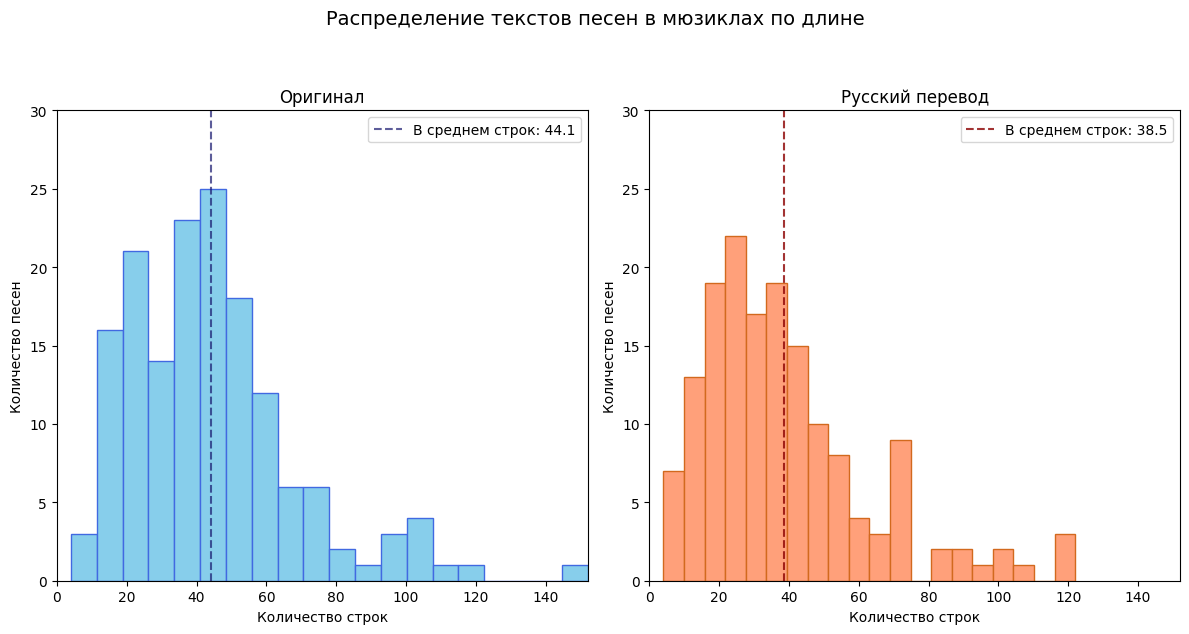

In [14]:
plt.figure(figsize=(12, 6))

# чтобы было в одном масштабе
max_value = max(songs['nlines_eng'].max(), songs['nlines_rus'].max())

# Английскиe
plt.subplot(1, 2, 1)
plt.hist(songs['nlines_eng'], bins=20, color='skyblue', edgecolor='royalblue', density=False)
plt.axvline(x=songs['nlines_eng'].mean(), color='midnightblue', alpha = 0.7, linestyle='--', label=f"В среднем строк: {songs['nlines_eng'].mean():.1f}")
plt.xlim(0, max_value)
plt.ylim(0, 30)
plt.legend()
plt.title('Оригинал')
plt.xlabel('Количество строк')
plt.ylabel('Количество песен')

# Русскиe
plt.subplot(1, 2, 2)
plt.hist(songs['nlines_rus'], bins=20, color='lightsalmon', edgecolor='chocolate', density=False)
plt.axvline(x=songs['nlines_rus'].mean(), color='darkred', alpha = 0.8, linestyle='--', label=f"В среднем строк: {songs['nlines_rus'].mean():.1f}")
plt.ylim(0, 30)
plt.xlim(0, max_value)
plt.legend()
plt.title('Русский перевод')
plt.xlabel('Количество строк')
plt.ylabel('Количество песен')

plt.suptitle('Распределение текстов песен в мюзиклах по длине', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Четверть корпуса составляет до 25 строк в длину, из них довольно много больше 10 и меньше 25. Слишком короткие песни малоинформативны - их не так много, и от этого не так сильно пострадает количество текстов, судя по графику. Посмотрим на песни, где менее 10 переносов строк:

In [15]:
songs[(songs['nlines_rus'] < 10) | (songs['nlines_eng'] < 10)][['musical', 'songtitle_eng',  'nlines_eng', 'nlines_rus']]

,musical,songtitle_eng,nlines_eng,nlines_rus
29,Chess,Chess,4,4
36,Chess,Pity The Child (Fragment),14,7
54,Jekyll & Hyde,Façade (Reprise 1),20,6
72,Jekyll & Hyde,Facade (Reprise 4) / Finale,13,6
95,Cats,Journey to the Heaviside Layer,8,8
112,Hair,Oh Great God Of Power,13,8
156,Sound of Music,Climb Ev'ry Mountain (Reprise),8,7


В Практически все они представляют из себя репризы - повторение фрагмента какой-либо другой композиции. Так что смело от них избавляемся.

Оставляем тексты, в которых и русский, и английский текст составляет **10 строчек и более**.

In [16]:
# сохраняем датафрейм без слишком коротких текстов - и заодно оставляем за рамками ненужные далее колонки
songs_filtered = songs[(songs['nlines_rus'] > 9) & (songs['nlines_eng'] > 9)][['musical', 'id', 'songtitle_eng', 'songtitle_rus', 'fin_eng', 'fin_rus']]
songs_filtered.head()

,musical,id,songtitle_eng,songtitle_rus,fin_eng,fin_rus
0,Mamma Mia!,0,"Honey, Honey","МИЛЫЙ, МИЛЫЙ","Honey honey, how he thrills me, a-ha, honey ho...","Милый, Милый,\nОн волнует меня\nМилый, Милый.\..."
1,Mamma Mia!,1,"Money, Money, Money","ДЕНЬГИ, ДЕНЬГИ, ДЕНЬГИ","I work all night, I work all day\nTo pay the b...","Работай день, работай ночь, чтоб как-то выкрут..."
2,Mamma Mia!,2,Thank You for the Music,СПАСИБО ТЕБЕ ЗА МУЗЫКУ,Thank you for the music\nThe songs I'm singing...,"Я скажу спасибо тебе за песни,\nИх мелодий хор..."
3,Mamma Mia!,3,Mamma Mia,МАМА МИЯ,I was cheated by you\nAnd I think you know whe...,"Ты меня обманул, сам ты помнишь когда?\nЯ реши..."
4,Mamma Mia!,4,Chiquitita,ЧИКИТИТА,"Chiquitita, tell me what's wrong\nI have never...","Чикитита, что же с тобой?\nЭто горе так внезап..."


## Оценка схожести оригиналов текстов и переводов на русский с LaBSE

### Создание моделей

In [82]:
# вариант 1 - просто модель "из коробки"
model_base = SentenceTransformer(
    'sentence-transformers/LaBSE', device='cpu' if not torch.cuda.is_available() else 'cuda')
# model_base = models.Transformer('sentence-transformers/LaBSE')

In [83]:
# прописываем прицельно, потому что автоматически выбиралось что-то не совсем то - с меньшим объемом токенов
tokenizer = models.Transformer('sentence-transformers/LaBSE').tokenizer

In [84]:
# и также попробуем модель с пулингом
word_embedding_model = models.Transformer('sentence-transformers/LaBSE')
pooling_model = models.Pooling(
    word_embedding_dimension=word_embedding_model.get_word_embedding_dimension(),
    pooling_mode='mean'
)

# готовая модель с пулингом
model_with_pooling = SentenceTransformer(modules=[model_base, pooling_model])


### Корректировка корпуса текстов

* Обзор того, насколько тексты помещаются в модель (на какое количество токенов их разбивает токенизатор). Выявление превышающих лимиты случаев
* Удаление слишком маленьких текстов песен. Определение по количеству строчек в тексте

In [74]:
def tokencount(text):
    '''Вычисляет количество токенов, на которые для подачи в модель поделится текст'''
    tokens = tokenizer.tokenize(text)
    num_tokens = len(tokens)

    return num_tokens


In [85]:
songs_filtered['tokens_eng'] = songs_filtered['fin_eng'].apply(tokencount)
songs_filtered['tokens_rus'] = songs_filtered['fin_rus'].apply(tokencount)

Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


In [86]:
# посмотрим, какие песни и сколько превышают лимит токенов
print(len(songs_filtered[songs_filtered['tokens_eng'] > 512]))

21


In [88]:
songs_filtered[songs_filtered['tokens_eng'] > 512][['musical', 'songtitle_eng', 'tokens_eng', 'tokens_rus']]

,musical,songtitle_eng,tokens_eng,tokens_rus
19,Mamma Mia!,Take a Chance on Me,545,341
22,Chess,Merano,828,774
24,Chess,Press Conference,615,539
31,Chess,Quartet (A Model Of Decoruim And Tranquility),565,540
42,Chess,The Soviet Machine,525,397
48,Chess,Endgame,626,779
53,Jekyll & Hyde,Facade,655,463
61,Jekyll & Hyde,Your Work- And Nothing More,683,527
64,Jekyll & Hyde,"Murder, Murder",960,883
74,Jekyll & Hyde,The Board Of Governors/ Jekyll's Plea,930,846


Все тексты, превышающие лимит модели, были просмотрены вручную. Особенно тщательно - случаи, где оригинал и перевод сильно расходятся в количестве токенов (например, id = 19, 42, 146):
* где-то парсинг захватил разговорную часть до/после/внутри текста песни, которая для нашей задачи не нужна -> разговорные вставки удалены
* несколько раз приклеивался кусок следующей песни -> удалено

Песни, которые несильно превышают лимит (от 512 до ~600) на обоих языках в примерно одинаковой мере, считаем нормальными.

In [89]:
songs_filtered[songs_filtered['tokens_eng'] > 600][['musical', 'songtitle_eng', 'tokens_eng', 'tokens_rus']]

,musical,songtitle_eng,tokens_eng,tokens_rus
22,Chess,Merano,828,774
24,Chess,Press Conference,615,539
48,Chess,Endgame,626,779
53,Jekyll & Hyde,Facade,655,463
61,Jekyll & Hyde,Your Work- And Nothing More,683,527
64,Jekyll & Hyde,"Murder, Murder",960,883
74,Jekyll & Hyde,The Board Of Governors/ Jekyll's Plea,930,846
76,Cats,Prologue: Jellicle Songs for Jellicle Cats,710,851
91,Cats,Skimbleshanks: The Railway Cat,745,790
133,Jesus Christ Superstar,The Last Supper,699,592


### Вычисление косинусной близости оригинальных текстов и их переводов

In [90]:
# оставим только нужные колонки
labse_songsdata = songs_filtered[['musical', 'songtitle_eng', 'songtitle_rus', 'id', 'fin_eng', 'fin_rus', 'tokens_eng', 'tokens_rus']]
labse_songsdata.head(2)

,musical,songtitle_eng,songtitle_rus,id,fin_eng,fin_rus,tokens_eng,tokens_rus
0,Mamma Mia!,"Honey, Honey","МИЛЫЙ, МИЛЫЙ",0,"Honey honey, how he thrills me, a-ha, honey ho...","Милый, Милый,\nОн волнует меня\nМилый, Милый.\...",186,259
1,Mamma Mia!,"Money, Money, Money","ДЕНЬГИ, ДЕНЬГИ, ДЕНЬГИ",1,"I work all night, I work all day\nTo pay the b...","Работай день, работай ночь, чтоб как-то выкрут...",317,313


In [91]:
# функция для вычисления схожести рус. и англ. текстов (базовая модель)
def calculating_similarity(text_en, text_ru):

    embedding_en = model_base.encode(text_en, convert_to_tensor=True)
    embedding_ru = model_base.encode(text_ru, convert_to_tensor=True)
    
    cos_sim = torch.cosine_similarity(embedding_en.unsqueeze(0), embedding_ru.unsqueeze(0)).item()
    
    return cos_sim

# модель с пулингом
def calculating_similarity_mod2(text_en, text_ru):

    embedding_en = model_with_pooling.encode(text_en, convert_to_tensor=True)
    embedding_ru = model_with_pooling.encode(text_ru, convert_to_tensor=True)
    
    cos_sim = torch.cosine_similarity(embedding_en.unsqueeze(0), embedding_ru.unsqueeze(0)).item()
    
    return cos_sim

In [92]:
# вычисляем косинусную близость пар и записываем в датафрейм
labse_songsdata['cosine_similarity'] = labse_songsdata.apply(lambda row: calculating_similarity(row['fin_eng'], row['fin_rus']), axis=1)
# с пуллингом
labse_songsdata['cosine_similarity_mod2'] = labse_songsdata.apply(lambda row: calculating_similarity_mod2(row['fin_eng'], row['fin_rus']), axis=1)

C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\3210751848.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['cosine_similarity'] = labse_songsdata.apply(lambda row: calculating_similarity(row['fin_eng'], row['fin_rus']), axis=1)
C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\3210751848.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['cosine_similarity_mod2'] = labse_songsdata.apply(lambda row: calculating_similarity_mod2(row['fin_eng'], row['fin_rus']), axis=1)


In [93]:
labse_songsdata.head(2)

,musical,songtitle_eng,songtitle_rus,id,fin_eng,fin_rus,tokens_eng,tokens_rus,cosine_similarity,cosine_similarity_mod2
0,Mamma Mia!,"Honey, Honey","МИЛЫЙ, МИЛЫЙ",0,"Honey honey, how he thrills me, a-ha, honey ho...","Милый, Милый,\nОн волнует меня\nМилый, Милый.\...",186,259,0.727766,0.825511
1,Mamma Mia!,"Money, Money, Money","ДЕНЬГИ, ДЕНЬГИ, ДЕНЬГИ",1,"I work all night, I work all day\nTo pay the b...","Работай день, работай ночь, чтоб как-то выкрут...",317,313,0.757002,0.826079


In [94]:
# посмотрим на косинусную близость в базовой модели и в модели с пуллингом
labse_songsdata[['cosine_similarity', 'cosine_similarity_mod2']].describe()

,cosine_similarity,cosine_similarity_mod2
count,150.000000,150.000000
mean,0.719281,0.843580
std,0.069210,0.040169
min,0.444329,0.710896
25%,0.688970,0.825653
50%,0.727586,0.846324
75%,0.767701,0.874227
max,0.839204,0.925174


Косинусная близость в модели с явно прописанным пулингом в целом выше и меньше колеблется.

In [95]:
# посмотрим, изменится ли ситуация, если весь текст привести к нижнему регистру
labse_songsdata['eng_lower'] = labse_songsdata['fin_eng'].apply(str.lower)
labse_songsdata['rus_lower'] = labse_songsdata['fin_rus'].apply(str.lower)

C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\1702122852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['eng_lower'] = labse_songsdata['fin_eng'].apply(str.lower)
C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\1702122852.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['rus_lower'] = labse_songsdata['fin_rus'].apply(str.lower)


In [96]:
# смотрим для текстов в одном регистре
# вычисляем косинусную близость пар и записываем в датафрейм
labse_songsdata['cosine_similarity_lower'] = labse_songsdata.apply(lambda row: calculating_similarity(row['eng_lower'], row['rus_lower']), axis=1)
# и для модели с пулингом тоже
labse_songsdata['cosine_similarity_lower_mod2'] = labse_songsdata.apply(lambda row: calculating_similarity_mod2(row['eng_lower'], row['rus_lower']), axis=1)

C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\1116363243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['cosine_similarity_lower'] = labse_songsdata.apply(lambda row: calculating_similarity(row['eng_lower'], row['rus_lower']), axis=1)
C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\1116363243.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['cosine_similarity_lower_mod2'] = labse_songsdata.apply(lambda row: calculating_similarity_mod2(row['eng_lower'], row['rus_

In [97]:
# вычисляем разницу
labse_songsdata['similarity_diff'] = labse_songsdata['cosine_similarity_lower'] - labse_songsdata['cosine_similarity']
labse_songsdata['similarity_diff_mod2'] = labse_songsdata['cosine_similarity_lower_mod2'] - labse_songsdata['cosine_similarity_mod2']

C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\3020618221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['similarity_diff'] = labse_songsdata['cosine_similarity_lower'] - labse_songsdata['cosine_similarity']
C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\3020618221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['similarity_diff_mod2'] = labse_songsdata['cosine_similarity_lower_mod2'] - labse_songsdata['cosine_similarity_mod2']


In [98]:
labse_songsdata[['cosine_similarity', 'cosine_similarity_lower', 'similarity_diff', 
'cosine_similarity_mod2', 'cosine_similarity_lower_mod2', 'similarity_diff_mod2']].describe()

,cosine_similarity,cosine_similarity_lower,similarity_diff,cosine_similarity_mod2,cosine_similarity_lower_mod2,similarity_diff_mod2
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,0.719281,0.717922,-0.001359,0.843580,0.846204,0.002624
std,0.069210,0.072054,0.021657,0.040169,0.041486,0.013222
min,0.444329,0.426179,-0.129902,0.710896,0.673291,-0.044859
25%,0.688970,0.692000,-0.013193,0.825653,0.826442,-0.003616
50%,0.727586,0.732322,-0.000768,0.846324,0.851499,0.003991
75%,0.767701,0.759087,0.010352,0.874227,0.874813,0.009002
max,0.839204,0.846947,0.053494,0.925174,0.914898,0.037848


Расхождения не кажутся существенными - можно обратить внимание только на некоторое изменение минимальной косинусной близости: с приведением к нижнему регистру она стала ниже, чем была: на ~0.13 в базовой модели и на 0.045 в модели с пулингом. Разница по остальным характеристикам совсем микроскопическая. 
Итак:
* снижение регистра нецелесообразно
* будем опираться на значения, полученные у модели с пулингом

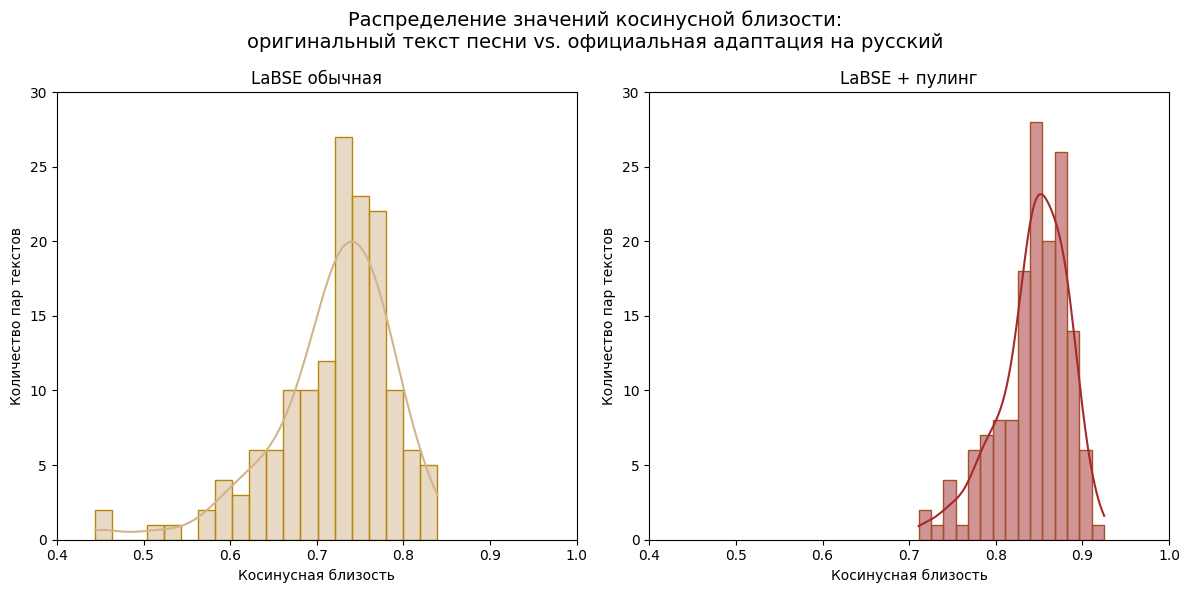

In [99]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

sns.histplot(labse_songsdata['cosine_similarity'], bins=20, kde=True, color='tan', edgecolor='darkgoldenrod')
plt.title('LaBSE обычная')
plt.xlabel('Косинусная близость')
plt.ylabel('Количество пар текстов')
plt.xlim(0.4, 1)
plt.ylim(0, 30)

plt.subplot(1, 2, 2)
sns.histplot(labse_songsdata['cosine_similarity_mod2'], bins=15, kde=True, color='brown', edgecolor='sienna')
plt.title('LaBSE + пулинг')
plt.xlabel('Косинусная близость')
plt.ylabel('Количество пар текстов')
plt.xlim(0.4, 1)
plt.ylim(0, 30)

plt.suptitle('Распределение значений косинусной близости:\nоригинальный текст песни vs. официальная адаптация на русский', fontsize=14)
plt.tight_layout()
plt.show()

### Результаты сравнения с LaBSE

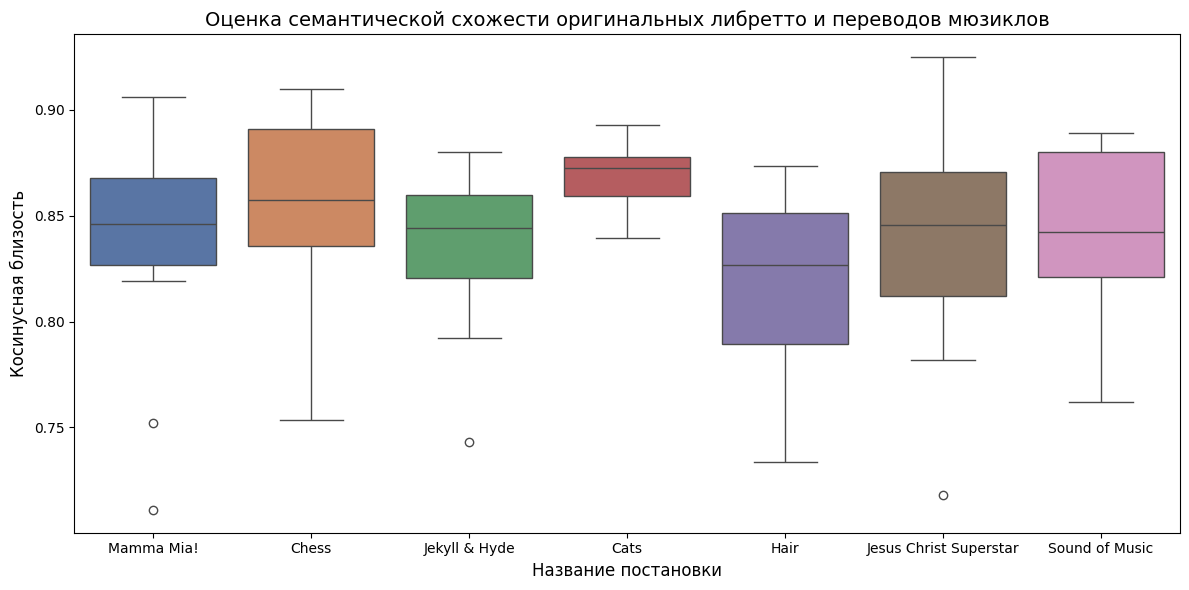

In [100]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='musical', y='cosine_similarity_mod2', data=labse_songsdata, hue = 'musical', palette = 'deep')
plt.title('Оценка семантической схожести оригинальных либретто и переводов мюзиклов', size = 14)
plt.ylabel('Косинусная близость', size = 12)
plt.xlabel('Название постановки', size = 12)
plt.xticks()
plt.tight_layout()
plt.show()

In [101]:
# добавим усредненное значение токенов, чтобы отразть размеры песен на графике
labse_songsdata['tokens_mean'] = labse_songsdata[['tokens_eng', 'tokens_rus']].mean(axis=1)

C:\Users\Butak\AppData\Local\Temp\ipykernel_16840\480205185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labse_songsdata['tokens_mean'] = labse_songsdata[['tokens_eng', 'tokens_rus']].mean(axis=1)


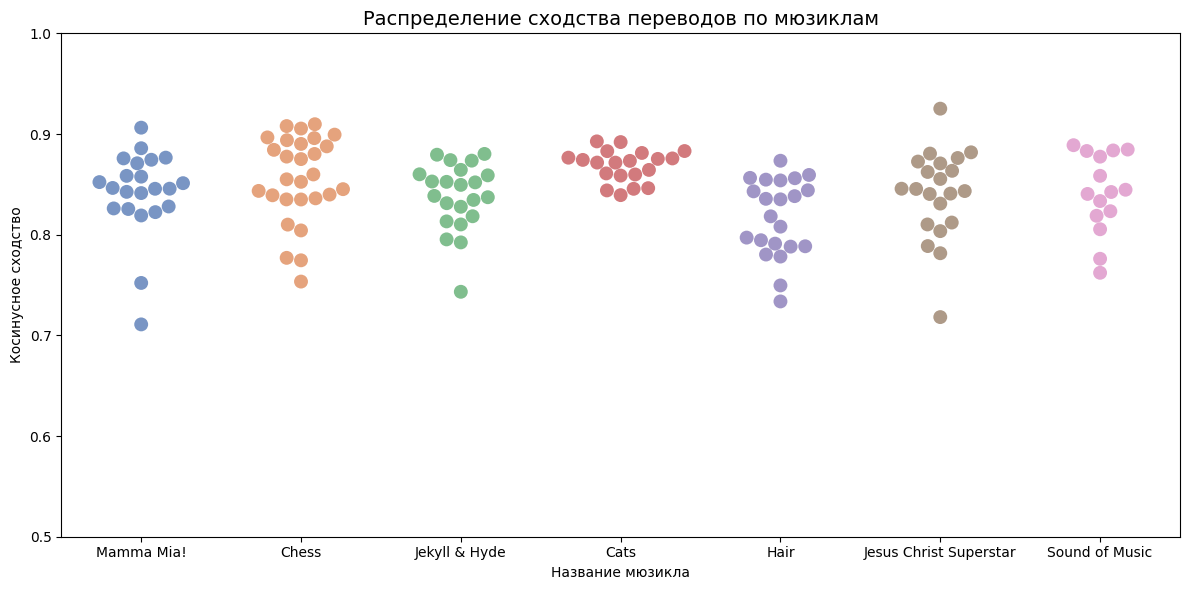

In [102]:
plt.figure(figsize=(12, 6))

sns.swarmplot(
    data=labse_songsdata,
    x='musical',
    y='cosine_similarity_mod2',
    palette='deep', hue='musical',
    size=10, alpha = 0.75
)

plt.title('Распределение сходства переводов по мюзиклам', fontsize = 14)
plt.xlabel('Название мюзикла')
plt.ylabel('Косинусное сходство')
plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

### Анализ наименее близких пар оригинал-перевод

In [ ]:
# выявим 5 худших результатов косинусной близости (по модели с пулингом)
top_worst = labse_songsdata.nsmallest(5, 'cosine_similarity')
top_overall = pd.concat([top_worst], keys=['lowest cos_sim'])

# Выводим только самую важную информацию для анализа
top_overall[['musical', 'songtitle_eng', 'songtitle_rus', 'cosine_similarity', 'fin_eng', 'fin_rus']]

musical          songtitle_eng  \
lowest cos_sim 68            Jekyll & Hyde     Facade (Reprise 3)   
               127  Jesus Christ Superstar         Poor Jerusalem   
               30                    Chess  The Arbiter (Reprise)   
               126  Jesus Christ Superstar         Simon Zealotes   
               116                    Hair   Three-Five-Zero-Zero   

                              songtitle_rus  cosine_similarity  \
lowest cos_sim 68         Фасад (реприза 3)           0.444329   
               127  Что есть высшая власть?           0.450420   
               30           АРБИТР. РЕПРИЗА           0.503566   
               126              Симон Зилот           0.528235   
               116        ПЕСНЯ "ЕДА ВОЙНЫ"           0.566511   

                                                              fin_eng  \
lowest cos_sim 68   If you live around here,\nLotsa people, I fear...   
               127  Neither you, Simon, nor the fifty thousand,\nN...   
               30   I'm on the case\nCan't be fooled\nAny objectio...   
               126  Christ you know I love you.\nDid you see I wav...   
               116  Ripped open by metal explosion\nCaught in barb...   

                                                              fin_rus  
lowest cos_sim 68   Лондон – яма с дерьмом, город страшных теней\n...  
               127  Честолюбец, рвущийся к власти\nИ свободы жажду...  
               30   Ты жульничаешь! \nТы получал подсказки от секу...  
               126  Власть твоя апогея достигла\nПламя вспыхнет, л...  
               116  Распорота когтем снаряда\nГруда тел, волна огн...

Сравним ключевые слова на русском и английском языке для наиболее и наименее схожих пар. Это может обнаружить, в состоят принципиальные расхождения и есть ли они.

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [117]:
def get_keywords(text, stop_words, top_n=10):
    ''' Получение n ключевых слов из текста.'''
    # Создаем модель и сразу подгоняем её под этот текст
    vectorizer = TfidfVectorizer(stop_words=stop_words).fit([text])
    
    # Получаем веса слов
    tfidf_scores = vectorizer.transform([text]).toarray()[0]
    
    # Получаем сами слова
    keywords = vectorizer.get_feature_names_out()
    
    # Сортируем слова по весу и берем топ-N
    top_keyword_indices = tfidf_scores.argsort()[-top_n:][::-1]
    return [(keywords[i], tfidf_scores[i]) for i in top_keyword_indices]

In [124]:
def compare_song(row):
    """
    Принимает строку DataFrame и выводит сравнение оригинала, перевода и их ключевых слов.
    """
    print(f"="*60)
    print(f"МЮЗИКЛ: {row['musical']}")
    print(f"ПЕСНЯ: {row['songtitle_eng']}  |  {row['songtitle_rus']}")
    print(f"СХОДСТВО: {row['cosine_similarity']:.3f}")
    print(f"="*60 + "\n")
    
    # Получаем ключевые слова
    kw_eng = get_keywords(row['fin_eng'], stop_words= stopwords_custom_en)
    kw_rus = get_keywords(row['fin_rus'],  stop_words= stopwords_custom_ru)
    
    print("АНГЛИЙСКИЙ ОРИГИНАЛ:")
    print(row['fin_eng'][:300] + "...") # Обрезаем для красоты
    print("\nКЛЮЧЕВЫЕ СЛОВА (ENG):")
    print(", ".join([word for word, score in kw_eng]))
    
    print("\n" + "="*30 + "\n")
    
    print("РУССКИЙ ПЕРЕВОД:")
    print(row['fin_rus'][:300] + "...")
    print("\nКЛЮЧЕВЫЕ СЛОВА (РУС):")
    print(", ".join([word for word, score in kw_rus]))
    
    print("\n" + "="*60 + "\n")



In [125]:
# Применяем функцию к нашим результатам
for idx, row in top_overall.iterrows():
    compare_song(row)

МЮЗИКЛ: Jekyll & Hyde
ПЕСНЯ: Facade (Reprise 3)  |  Фасад (реприза 3)
СХОДСТВО: 0.444

АНГЛИЙСКИЙ ОРИГИНАЛ:
If you live around here,
Lotsa people, I fear,
Will make promises
They will not honour, my dear,
An' the truth is,
You end up getting scarred!
There's a beast at the door,
An' he's wild an' he's free,
But we don't let him in,
'Cause we don't want to see
what is lurking
Right behind the facade!...

КЛЮЧЕВЫЕ СЛОВА (ENG):
wild, want, truth, see, scarred, right, promises, people, make, lurking


РУССКИЙ ПЕРЕВОД:
Лондон – яма с дерьмом, город страшных теней
Бродит смерть за углом, здесь не ищут друзей
Карта бита, жизнь дешевле гроша
Шанс один из пяти – будь хитра, не зевай
Хочешь выжить – плати, или вмиг пропадай
Эти игры называют фасад
Всюду мрак, здесь цена душе - медяк
Боль чужая здесь пустяк
Здесь грех п...

КЛЮЧЕВЫЕ СЛОВА (РУС):
фасад, яма, шанс, чужая, хочешь, цена, хитра, углом, теней, страшных


МЮЗИКЛ: Jesus Christ Superstar
ПЕСНЯ: Poor Jerusalem  |  Что есть высшая власть?
С

# II. Поиск расхождений в оригинальных либретто и переводах

Общее представление о сходстве либретто мюзиклов в оригинале и на русском получено. Перейдем к более наглядному сравнению текстов. Инструменты:
* облака слов
* ключевые слова

Сравнение проводится:
* для каждого **из мюзиклов в целом** (т.е. объединив все его песни в один текст), чтобы более наглядно представить то, насколько тексты оригинальных мюзиклов и переводов на русский близки, а также это позволит быстро увидеть расхождения при их наличии.
* в двух вариантах обработки текстов:
    * С **сокращением повторяющихся строк** в песне - нередко одни и те же строки повторяются несклько раз подряд, плюс наличие припевов. Это должно прямым образом влиять на результаты анализа частотности. Так структура и специфика текстов будут меньше влиять на результаты
    * **Изначальная версия** без дополнительных сокращений 

In [20]:
from wordcloud import WordCloud

In [123]:
?WordCloud

Init signature:
WordCloud(
    font_path=None,
    width=400,
    height=200,
    margin=2,
    ranks_only=None,
    prefer_horizontal=0.9,
    mask=None,
    scale=1,
    color_func=None,
    max_words=200,
    min_font_size=4,
    stopwords=None,
    random_state=None,
    background_color='black',
    max_font_size=None,
    font_step=1,
    mode='RGB',
    relative_scaling='auto',
    regexp=None,
    collocations=True,
    colormap=None,
    normalize_plurals=True,
    contour_width=0,
    contour_color='black',
    repeat=False,
    include_numbers=False,
    min_word_length=0,
    collocation_threshold=30,
)
Docstring:     
Word cloud object for generating and drawing.

Parameters
----------
font_path : string
    Font path to the font that will be used (OTF or TTF).
    Defaults to DroidSansMono path on a Linux machine. If you are on
    another OS or don't have this font, you need to adjust this path.

width : int (default=400)
    Width of the canvas.

height : int (default=2

In [25]:
def desongfication(libretto):
    '''Устраняет характерную черту песенных текстов - повторение строк и целых фрагментов(припевы)'''
    
    text_no_repetition = []
    # бывает, что одна и та же строчка текста повторяется несколько раз, но с разными знаками препинания - сначала как вопрос, потом утверждение и т.д.
    # поэтому сразу избавимся от знаков пунктуации, характерных для конца предложения, и будем сравнивать строки без них
    text = re.sub(r'[\!\?(?:\.\.\.)]', ' ', libretto)
    text = re.sub(r'\s\n', '\n', text)

    text_split = text.split('\n')
    for line in text_split:
        if line not in text_no_repetition:
            text_no_repetition.append(line)
    
    edited = '\n'.join(text_no_repetition)

    return edited

### Предобработка текстов
Нужна более продвинутая обработка слов, чем для LaBSE, причем для каждого языка свой пайплайн, поэтому выстроим ее сначала.

* расширение списков стоп-слов для русского и английского, чтобы убрать из облаков имена персонажей, какие-то специфические моменты конкретных либретто, которые не несут практической пользы, но занимают высокие позиции по частотности
* перевод в нижний регистр, замена всех пробельных символов на один пробел, удаление всего, что не пунктуация
* замена Ё на Е (русский)
* токенизация и лемматизация (русский - pymorphy3, английский - spacy)
* удаление стоп-слов
* склейка лемматизированных токенов в одну строку для передачи в wordcloud


In [26]:
# предобработка
import nltk
from nltk import word_tokenize
from nltk import sent_tokenize

# стоп-слова
from nltk.corpus import stopwords
stopwords_ru = stopwords.words('russian')
stopwords_en = stopwords.words('english')

# лемматизация - rus
from pymorphy3 import MorphAnalyzer 
morph = MorphAnalyzer()

# лемматизация - en
import spacy
nlp = spacy.load('en_core_web_sm')


#### Дополнение списков стоп-слов

In [31]:
# избавимся от персонажей "Кошек" в тексте - их много и имена специфические, поэтому удобнее их выудить 
characters_raw = "['МИСС ДЖЕННИ И ВИКТОРИЯ:', 'ТАНТОМАЙЛ И КОРИКОПЭТ:', 'СТАРИК ДЬЮТЕРОНОМИ:', 'МИСТЕР МИСТОФЕЛИС:', 'РАМ-ТАМ-ТАГГЕР:', 'МАНГОДЖЕРРИ:', 'ДЖЕЛЛИЛОРУМ:', 'СКИМБЛШЕНКС:', 'БОМБАЛУРИНА:', 'РАМПЛТИЗЕР:', 'МАНКУСТРАП:', 'ГРИЗАБЕЛЛА:', 'ПОНСИВАЛЬ:', 'АСПАРАГУС:', 'КАССАНДРА:', 'ДЖЕМАЙМА:', 'АНСАМБЛЬ:', 'ДЕМЕТРА:', 'АДМЕТУС:', 'АЛОНЗО:'], ['АНСАМБЛЬ:'], ['МИСТЕР МИСТОФЕЛИС:', 'МАНКУСТРАП:', 'АНСАМБЛЬ:'], ['МИСС ДЖЕННИ:', 'МАНКУСТРАП:', 'АНСАМБЛЬ:'], ['МИСТЕР МИСТОФЕЛИС:', 'РАМ-ТАМ-ТАГГЕР:', 'РАМ-ТАМ-ТАГГЕР', 'БОМБАЛУРИНА:', 'АНСАМБЛЬ:'], ['ДЕМЕТРА И БОМБАЛУРИНА:', 'БОМБАЛУРИНА:', 'ГРИЗАБЕЛЛА:', 'АНСАМБЛЬ:', 'ДЕМЕТРА:'], ['БАСТОФЕР ДЖОНС:', 'ДЖЕЛЛИЛОРУМ:', 'МИСС ДЖЕННИ:', 'БОМБАЛУРИНА:', 'АНСАМБЛЬ:'], ['МАНГОДЖЕРРИ И РАМПЛТИЗЕР:', 'МАНГОДЖЕРРИ И РАМПЛТИЗЕР', 'МАНГОДЖЕРРИ:', 'РАМПЛТИЗЕР:', 'АНСАМБЛЬ:'], ['ТАНТОМАЙЛ И КОРИКОПЭТ:', 'СТАРИК ДЬЮТЕРОНОМИ:', 'МИСТЕР МИСТОФЕЛИС:', 'РАМ-ТАМ-ТАГГЕР:', 'МАНКУСТРАП:', 'АНСАМБЛЬ:'], ['МИСТЕР МИСТОФЕЛИС И ПОНСИВАЛЬ:', 'ВИКТОРИЯ И ДЖЕМАЙМА:', 'СТАРИК ДЬЮТЕРОНОМИ:', 'РАМ-ТАМ-ТАГГЕР:', 'ДЖЕЛЛИЛОРУМ:', 'СКИМБЛШЕНКС:', 'МИСС ДЖЕННИ:', 'БОМБАЛУРИНА:', 'ТАМБЛБРУТУС:', 'КАССАНДРА:', 'ПОНСИВАЛЬ:', 'АСПАРАТУС:', 'АНСАМБЛЬ:', 'ДЕМЕТРА:', 'АЛОНЗО:'], ['СТАРИК ДЬЮТЕРОНОМИ:', 'АНСАМБЛЬ:', 'ДЖЕМАЙМА:'], ['ДЖЕЛЛИЛОРУМ:', 'АСПАРАГУС:'], ['ГРОУЛТАЙГЕР И ГРИДДЛБОН:', 'МИСТЕР МИСТОФЕЛИС:', 'РАМ-ТАМ-ТАГГЕР:', 'ГРОУЛТАЙГЕР:', 'СКИМБЛШЕНКС:', 'МАНКУСТРАП:', 'ГРИДДЛБОН:', 'АЛОНЗО:', 'СИАМЦЫ:'], ['ГРОУЛТАЙГЕР И ГРИДДЛБОН:', 'ГРОУЛТАЙГЕР:', 'ГРИДДЛБОН:', 'АНСАМБЛЬ:'], ['ПРЕДВОДИТЕЛЬ СИАМЦЕВ:', 'ГРОУЛТАЙГЕР:', 'СИАМЦЫ:'], ['СТАРИК ДЬЮТЕРОНОМИ:', 'СКИМБЛШЕНКС:', 'РАМПЛТИЗЕР:', 'АНСАМБЛЬ:'], ['БОМБАЛУРИНА И ДЕМЕТРА:', 'БОМБАЛУРИНА:', 'АНСАМБЛЬ:', 'ДЕМЕТРА:'], ['РАМ-ТАМ-ТАГГЕР:', 'АНСАМБЛЬ:'], ['ГРИЗАБЕЛЛА И ДЖЕМАЙМА:', 'ГРИЗАБЕЛЛА:', 'МАНКУСТРАП:', 'ДЖЕМАЙМА:'], ['АНСАМБЛЬ:'], ['СТАРИК ДЬЮТЕРОНОМИ:'"
characters_edited = re.sub(r"[\]'\,\[\:]", '', characters_raw)
characters_edited = re.sub(r" И ", ' ', characters_edited)


In [32]:
characters_edited = characters_edited.lower().split(sep=' ')
to_delete = list(set(characters_edited))
print(len(to_delete))
print(to_delete)

34
['адметус', 'гризабелла', 'кассандра', 'дженни', 'сиамцы', 'аспарагус', 'мисс', 'аспаратус', 'джеллилорум', 'дьютерономи', 'понсиваль', 'мангоджерри', 'предводитель', 'гроултайгер', 'виктория', 'тантомайл', 'рамплтизер', 'скимблшенкс', 'алонзо', 'мистофелис', 'джонс', 'гриддлбон', 'старик', 'джемайма', 'корикопэт', 'бастофер', 'деметра', 'тамблбрутус', 'сиамцев', 'мистер', 'рам-там-таггер', 'бомбалурина', 'ансамбль', 'манкустрап']


In [53]:

# '', '', '', '', '', '', '', '', 
# дополним списки стоп-слов
stopwords_ru_new = ['мой', 'твой', 'ты', 'свой', 'ль', 'сей', 'что', 'весь', 'всё', 'ах', 'иль', 'ещё', 'который',
                                        'каждый', 'б', 'из-за', '--', 'это', 'пред', 'наш', 'ваш', 'чей', 'меж', '-', 'я-то', 'о', 'очень', 'вовсе', 'весьма', 'нужно', 'ло',
                                        'ку', 'лейди', 'оди', 'лейи', 'лейя', 'лейио', 'адья', 'охо', 'ипо', 'о', 'осанна', 'маня', 'макавитя', 'лио',
                                        'до', 'ре', 'ми', 'фа', 'соль', 'ля', 'си','еще', 'джекилл', 'хайд', 'мария', 'генри', 'джекилла', 'мамма', 'мия', 'мерано', 'па', 'ингланд',
                                        'джелли', 'рам', 'билли', 'санный', 'оди', 'мария', 'хей', 'эй', 'лейо', 'хо', 'ходи-лейи', 'квин', 'квино', 'ингланда', 'хара',
                                        'кришна', 'донна', 'иисус', 'христос', 'иуда', 'кайаф', 'кайафа', 'дэнсинга', 'ход', 'ходя', 'страйд', 'эмма', 'дэнверс', 'рам', 'там', 'таггер',
                                        'знать', 'мочь', 'ку-ку', 'ка', 'джелли-кот', 'словно', 'сказать', 'смочь', 'пусть', 'стать', 'сюда', 'значит', 'думать', 'снова', 'год', 'день',
                                        'просто', 'ходи-лейя', 'лейи-одить', 'лейи-оди-лейи-оди-лейио'   
                                        ]
stopwords_custom_ru = stopwords_ru + stopwords_ru_new + to_delete

stopwords_en_new = ['oh', 'hey', 'o', 'hmm', 'oo', 'odl', 'layee', 'do', 're', 'mi', 'fa', 'sol', 'la', 'ti', 'ode', 'jekyll', 'hyde', 'henry', 'mr',
                    'hosanna', 'jellicle', 'caiapha', 'jesus', 'christ', 'juda', 'judas', 'ha', 'voulez', 'vous', 'mamma', 'mia', 'merano', 'odllayee', 'ee', 'england', 
                    'lo', 'donna', 'rama', 'krishna', 'sanna', 'jc',  'bombalurina', 'tugger', 'quaxo',  'macavity', 'mungojerrie', 'bustopher', 'skimbleshank', 'jones', 
                    'growltiger', 'billy', 'skimble', 'know', 'deuteronomy', 'think', 'man', 'let', 'thing', 'maria', 'get', 'tum', 'ram',  'go', 'come', 'year', 'honey'   ]
stopwords_custom_en = stopwords_en + stopwords_en_new


#### Функции препроцессинга для каждого из языков отдельно

In [54]:
def preprocessing_ru(text):
    edited = text.lower()
    edited = re.sub(r'\s+', ' ', edited) # замена всех пробельных символов на обычный пробел
    edited = re.sub(r' - ', '', edited) # убираем дефисы, которые на самом деле не дефисы (не внутри слова)
    edited = re.sub(r'ё', 'е', edited)
    edited = re.sub(r'[^А-Яа-я -]', '', edited) # удаление всего, что не кириллица и не дефис и пробел

    tokenized = word_tokenize(edited) # токенизация по словам

    lemmatized = [morph.parse(token)[0].normal_form for token in tokenized] # лемматизация

    tokens_clean = [token for token in lemmatized if token not in stopwords_custom_ru] # очистка от стоп-слов

    return tokens_clean

def preprocessing_en(text):
    edited = text.lower()
    edited = re.sub(r'\s+', ' ', edited) # замена всех пробельных символов на обычный пробел

    tokenized = nlp(edited) # токенизация по словам - здесь через spacy
    # чистим от пробелов, пунктуации и стоп-слов
    tokenized_clean = [token for token in tokenized if not token.is_space and not token.is_punct and not token.is_stop]
    
    lemmatized = [token.lemma_ for token in tokenized_clean] # лемматизация
    
    # spacy возвращает штуки вроде 'I' в верхний регистр, так что понизим обратно
    tokens_clean = [token for token in lemmatized if token not in stopwords_custom_en] # очистка от наших кастомных стоп-слов - на всякий
        
    return tokens_clean

def merging_tokens(tokens_list):
    '''склеивает список токенов в одну строку'''
    tokens_string = ' '.join(tokens_list)

    return tokens_string

#### Создание версии текстов, где не будет идентичных строк

In [35]:
# вариант без повторяющихся строчек в песнях - создаем в изначальном датафрейме
songs_filtered['no_repetition_eng'] = songs_filtered['fin_eng'].apply(desongfication)
songs_filtered['no_repetition_rus'] = songs_filtered['fin_rus'].apply(desongfication)

In [36]:
# сколько строчек было снесено как повторяющихся
songs_filtered['diff_eng'] = songs_filtered['fin_eng'].str.count('\n') - songs_filtered['no_repetition_eng'].str.count('\n')
songs_filtered['diff_rus'] = songs_filtered['fin_rus'].str.count('\n') - songs_filtered['no_repetition_rus'].str.count('\n')

In [37]:
diff_eng_values = songs_filtered.groupby('musical')['diff_eng'].mean()
diff_rus_values = songs_filtered.groupby('musical')['diff_rus'].mean()

In [38]:
# насколько уменьшилось количество строк в целом по мюзиклу
pd.DataFrame([diff_eng_values, diff_rus_values]).T

,diff_eng,diff_rus
musical,,
Cats,5.700000,4.550000
Chess,5.392857,3.964286
Hair,10.090909,3.181818
Jekyll & Hyde,5.045455,3.681818
Jesus Christ Superstar,8.761905,8.666667
Mamma Mia!,18.000000,9.818182
Sound of Music,9.266667,16.733333


На некоторых текстах либретто разница заметна: Mamma Mia, Sound of Music. Однако количество удаленных повторов распределено неравномерно - большая разница между оригиналом и переводом. Это наводит на мысль о том, что, вероятно, в либретто может быть разное разбиение на строки - и то, что на одном языке идентифицировано как повторы и удалено, на другом языке просто изначально идет на одной строке

#### Подготовка текстов для работы

In [55]:
# версия с сокращениями
songs_filtered['tokenized_eng'] = songs_filtered['no_repetition_eng'].apply(preprocessing_en)
songs_filtered['tokenized_rus'] = songs_filtered['no_repetition_rus'].apply(preprocessing_ru)

songs_filtered['merged_clean_eng'] = songs_filtered['tokenized_eng'].apply(merging_tokens)
songs_filtered['merged_clean_rus'] = songs_filtered['tokenized_rus'].apply(merging_tokens)


In [56]:
# изначальная версия, из которой не удалялись повторы
songs_filtered['tokenized_eng_full'] = songs_filtered['fin_eng'].apply(preprocessing_en)
songs_filtered['tokenized_rus_full'] = songs_filtered['fin_rus'].apply(preprocessing_ru)

songs_filtered['merged_full_eng'] = songs_filtered['tokenized_eng_full'].apply(merging_tokens)
songs_filtered['merged_full_rus'] = songs_filtered['tokenized_rus_full'].apply(merging_tokens)


In [57]:
# оставляем только нужные колонки
wc_data = songs_filtered[['musical', 'id', 'songtitle_eng', 'songtitle_rus', 
                          'merged_clean_eng', 'merged_clean_rus', 'merged_full_eng', 'merged_full_rus']]
wc_data.head(2)

,musical,id,songtitle_eng,songtitle_rus,merged_clean_eng,merged_clean_rus,merged_full_eng,merged_full_rus
0,Mamma Mia!,0,"Honey, Honey","МИЛЫЙ, МИЛЫЙ",thrill nearly kill hear want mean love machine...,милый милый волновать милый милый погубить сво...,thrill nearly kill hear want mean love machine...,милый милый волновать милый милый милый милый ...
1,Mamma Mia!,1,"Money, Money, Money","ДЕНЬГИ, ДЕНЬГИ, ДЕНЬГИ",work night work day pay bill pay ai sad single...,работать работать ночь как-то выкрутиться беда...,work night work day pay bill pay ai sad single...,работать работать ночь как-то выкрутиться беда...


### Обзор расхождений при *сокращении* повторяющихся строк в тексте

##### Подготовка данных для удобства

In [58]:
# пределываем данные в длинный формат с помощью melt
wc_long = pd.melt(
    frame=wc_data,
    id_vars=['musical', 'id'],  
    value_vars=[
        'songtitle_eng', 'songtitle_rus',
        'merged_clean_eng', 'merged_clean_rus'],
    var_name='variable', 
    value_name='value'    
)

wc_long[['base', 'lang']] = wc_long['variable'].str.extract(r'(songtitle|merged_clean)_(\w+)')

wc_long.rename(columns={'value': 'text'}, inplace=True)

wc_long['title'] = wc_long.apply(
    lambda row: row['text'] if row['base'] == 'songtitle' else None,
    axis=1
)
wc_long['text'] = wc_long.apply(
    lambda row: row['text'] if row['base'] == 'merged_clean' else None,
    axis=1
)

# финализируем
wc_long.drop(columns=['variable', 'base'], inplace=True)
wc_long = wc_long.pivot_table(
    index=['musical', 'id', 'lang'],
    columns=None,
    aggfunc=lambda x: ''.join(x.dropna()),
    fill_value=''
).reset_index()

wc_long = wc_long[['musical', 'id', 'lang', 'title', 'text']]

In [59]:
wc_long.head(2)

,musical,id,lang,title,text
0,Cats,76,eng,Prologue: Jellicle Songs for Jellicle Cats,blind bear dark look king sit throne bite bad ...
1,Cats,76,rus,ПРОЛОГ. ДЖЕЛЛИ-ПЕСНИ,родиться слепой видеть тьма упасть высота невр...


##### Облако слов


In [60]:
# для удобства пропишем общие для облаков слов параметры отдельно
wc_params = {
    'width': 600,
    'height': 300,
    'background_color': 'white',
    'colormap': 'managua',
    'max_words': 120,
    'collocations': False, # n-граммы
    'normalize_plurals': True,
    'random_state' : 22,
    'max_font_size' : 150
    # 'min_font_size' : 4    
}

In [45]:
all_musicals = wc_long['musical'].unique()
num_musicals = len(all_musicals)

Cats - облако создано
Chess - облако создано
Hair - облако создано
Jekyll & Hyde - облако создано
Jesus Christ Superstar - облако создано
Mamma Mia! - облако создано
Sound of Music - облако создано


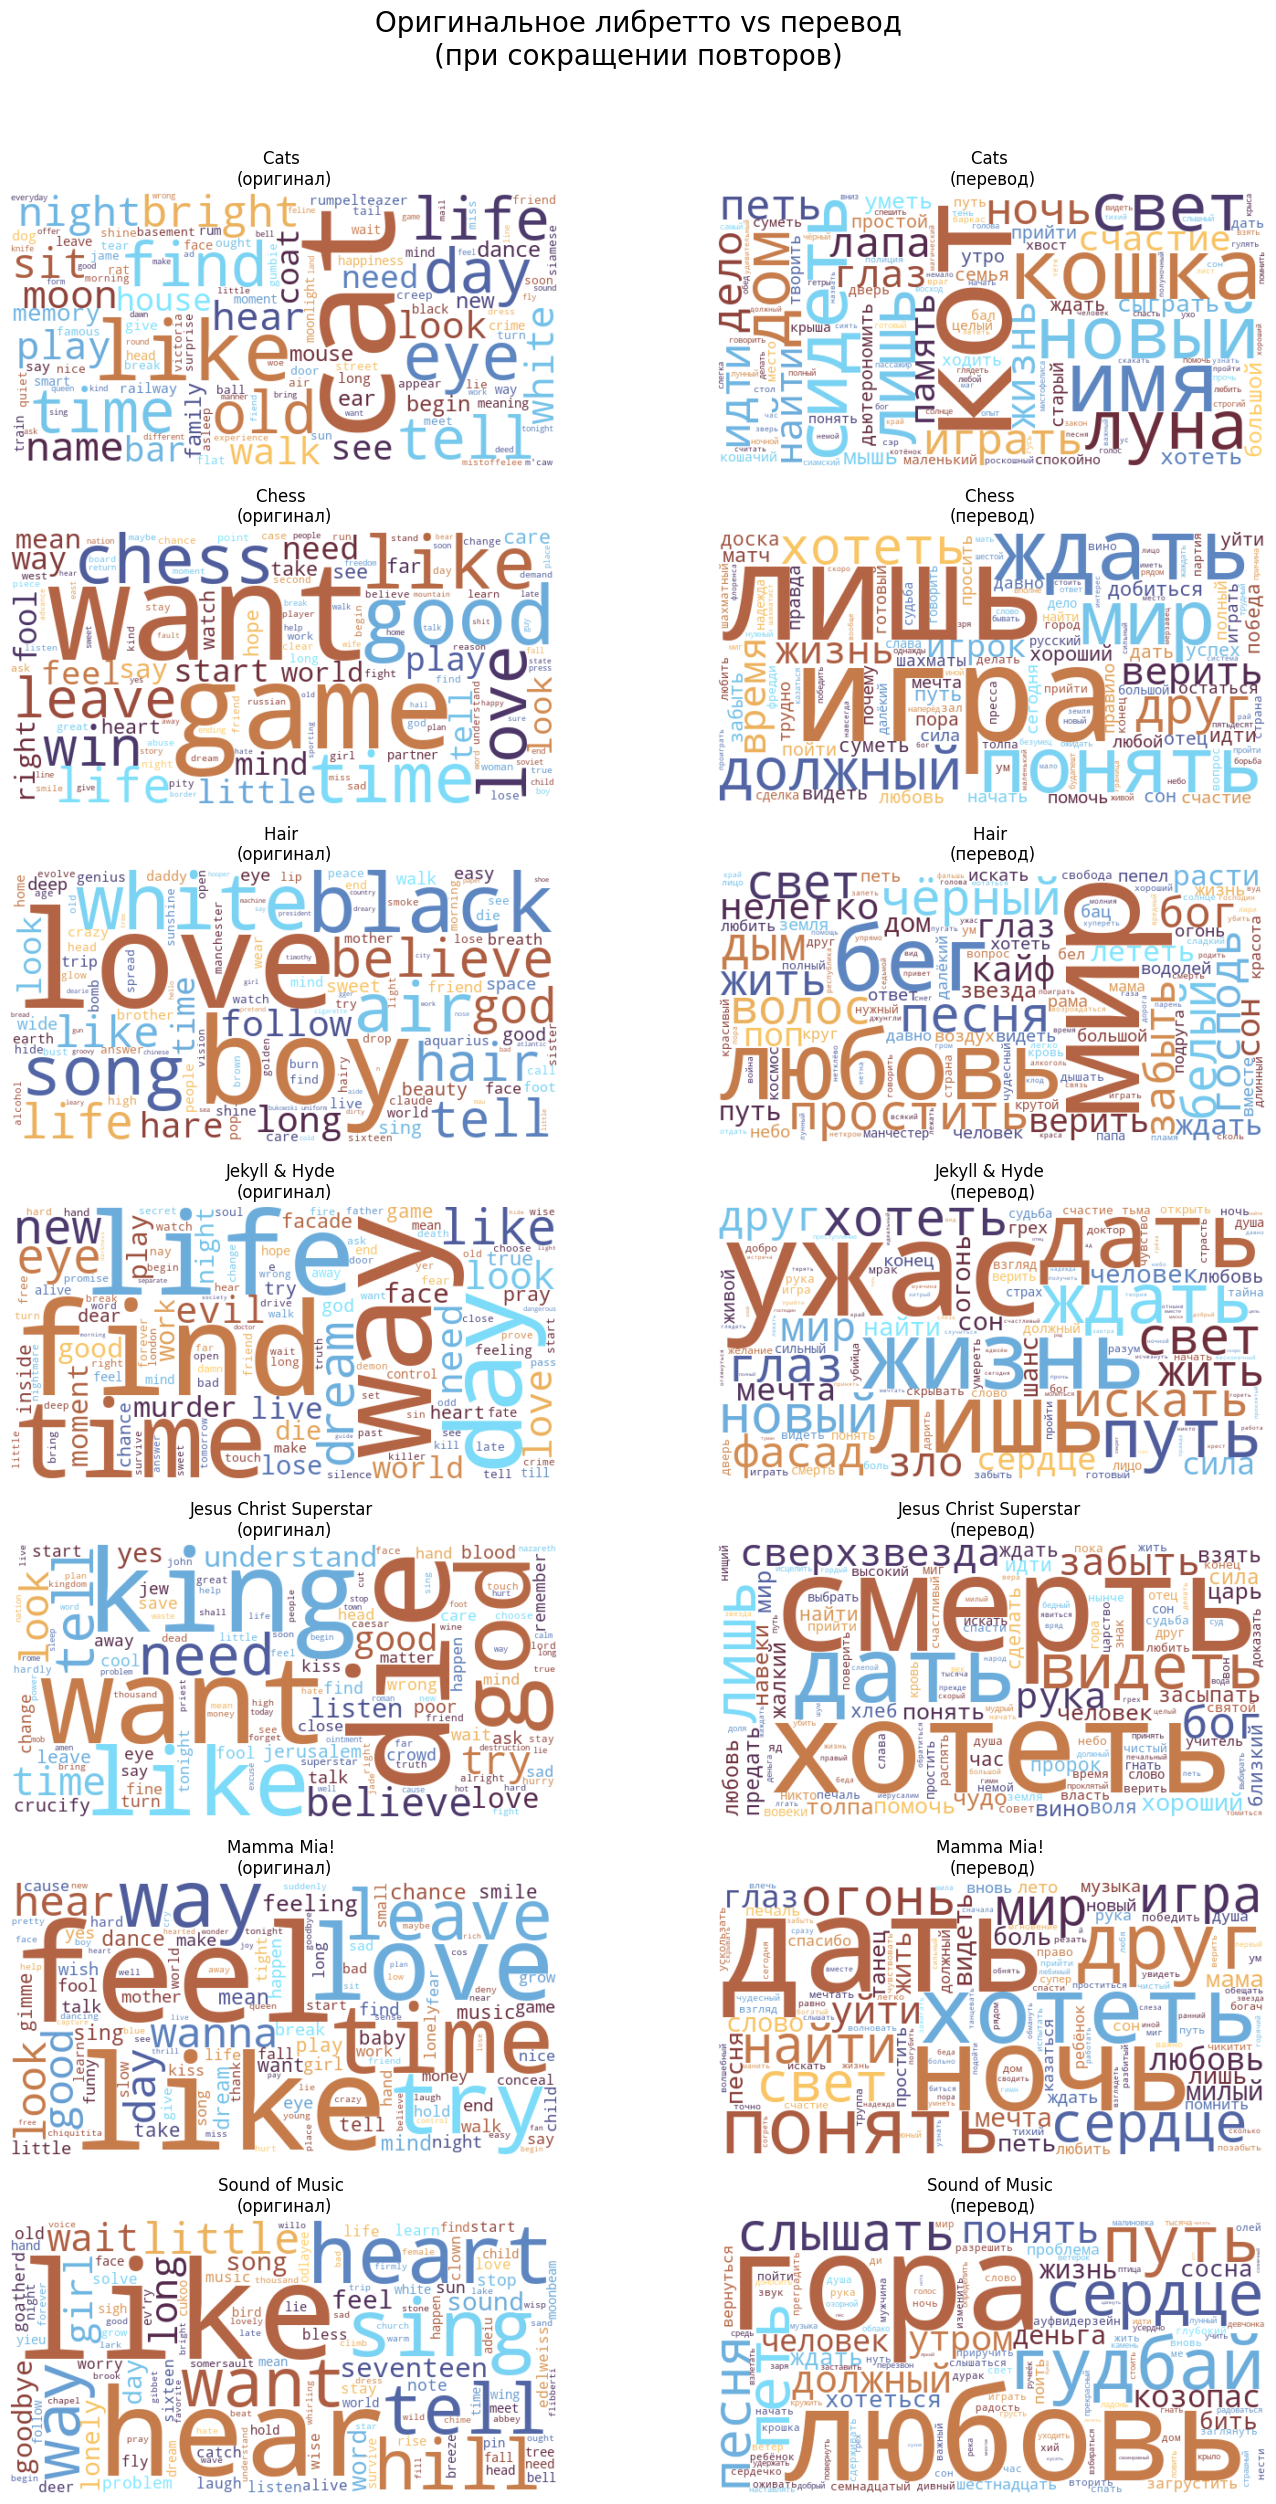

In [61]:
# пространство для всех графиков
fig, axes = plt.subplots(nrows=num_musicals, ncols=2, figsize=(15, num_musicals * 3.5))
fig.suptitle('Оригинальное либретто vs перевод\n(при сокращении повторов)', fontsize=20, y=1.02)


# проходимся по мюзиклам
for idx, musical_name in enumerate(all_musicals):
    
    # слева будет идти английский, справа русский
    ax_en = axes[idx][0] 
    ax_ru = axes[idx][1] 

    # подготовка данных для каждого мюзикла - отбираем отдельно русские и английские песни
    df_musical = wc_long[wc_long['musical'] == musical_name]
    df_en = df_musical[df_musical['lang'] == 'eng']
    df_ru = df_musical[df_musical['lang'] == 'rus']

    # склеиваем тексты песен мюзикла на каждом из языков в одну сроку
    text_english = ' '.join(df_en['text'].tolist())
    text_russian = ' '.join(df_ru['text'].tolist())

    # облако слов - английский
    wc_params.update(stopwords=stopwords_custom_en)
    wordcloud_en = WordCloud(**wc_params).generate(text_english)
    ax_en.imshow(wordcloud_en, interpolation='bilinear')
    ax_en.set_title(f'{musical_name} \n(оригинал)', fontsize=12)
    ax_en.axis('off')   

    # облако слов - русский
    wc_params.update(stopwords=stopwords_custom_ru)
    wordcloud_ru = WordCloud(**wc_params).generate(text_russian)
    ax_ru.imshow(wordcloud_ru, interpolation='bilinear')
    ax_ru.set_title(f'{musical_name} \n(перевод)', fontsize=12)
    ax_ru.axis('off') 
    
    # для спокойствия души
    print(f"{musical_name} - облако создано")



plt.tight_layout(h_pad=1.5) 
plt.show()

#### Ключевые слова

In [50]:
from collections import Counter

In [62]:
# соберем ключевые слова для каждого мюзикла на обоих языках
results = []
all_musicals = wc_long['musical'].unique()
languages = ['eng', 'rus']
corpuses_overall = []

In [63]:
for musical in all_musicals:
    keywords_by_lang = {}
    
    for lang in languages:
        df_subset = wc_long[(wc_long['musical'] == musical) & (wc_long['lang'] == lang)]
        corpus = ' '.join(df_subset['text'].astype(str))
        corpuses_overall.append(corpus) # сохраним на всякий склеенные тексты
        words = corpus.split()
        word_counts = Counter(words)
        top_words = word_counts.most_common(12)
        keywords_by_lang[lang] = ', '.join([word for word, _ in top_words])
    
    results.append({
        'musical': musical,
        'eng_keywords': keywords_by_lang['eng'],
        'rus_keywords': keywords_by_lang['rus']
    })


In [64]:
for res in results:
    print(res['musical'])  
    print(f"\teng: {res['eng_keywords']}")  # Ключевые слова на английском
    print(f"\trus: {res['rus_keywords']}")  # Ключевые слова на русском
    print('\n')

Cats
	eng: cat, like, eye, find, time, day, life, old, tell, bright, sit, night
	rus: кот, имя, сидеть, новый, свет, дом, кошка, лишь, луна, играть, ночь, идти


Chess
	eng: want, game, good, like, chess, time, love, leave, win, life, play, feel
	rus: лишь, игра, ждать, понять, мир, должный, хотеть, друг, верить, время, жизнь, игрок


Hair
	eng: love, boy, black, white, song, believe, air, hair, tell, life, god, like
	rus: мир, любовь, бег, чёрный, простить, песня, свет, дым, белый, волос, бог, господь


Jekyll & Hyde
	eng: way, find, life, time, day, like, dream, eye, new, look, love, evil
	rus: ужас, лишь, жизнь, дать, ждать, путь, новый, свет, хотеть, глаз, искать, фасад


Jesus Christ Superstar
	eng: die, want, king, god, like, need, tell, believe, try, time, look, good
	rus: смерть, дать, видеть, хотеть, лишь, бог, сверхзвезда, забыть, хороший, рука, мир, чудо


Mamma Mia!
	eng: feel, like, love, time, try, way, leave, hear, good, wanna, day, look
	rus: дать, ночь, хотеть, понять,

### Обзор расхождений для текстов в *изначальном* виде

#### Подготовка данных

In [65]:
# пределываем данные в длинный формат с помощью melt
wc_long_full = pd.melt(
    frame=wc_data,
    id_vars=['musical', 'id'],  
    value_vars=[
        'songtitle_eng', 'songtitle_rus',
        'merged_full_eng', 'merged_full_rus'],
    var_name='variable', 
    value_name='value'    
)

wc_long_full[['base', 'lang']] = wc_long_full['variable'].str.extract(r'(songtitle|merged_full)_(\w+)')

wc_long_full.rename(columns={'value': 'text'}, inplace=True)

wc_long_full['title'] = wc_long_full.apply(
    lambda row: row['text'] if row['base'] == 'songtitle' else None,
    axis=1
)
wc_long_full['text'] = wc_long_full.apply(
    lambda row: row['text'] if row['base'] == 'merged_full' else None,
    axis=1
)

# финализируем
wc_long_full.drop(columns=['variable', 'base'], inplace=True)
wc_long_full = wc_long_full.pivot_table(
    index=['musical', 'id', 'lang'],
    columns=None,
    aggfunc=lambda x: ''.join(x.dropna()),
    fill_value=''
).reset_index()

wc_long_f = wc_long_full[['musical', 'id', 'lang', 'title', 'text']]

In [215]:
wc_long_full.head(2)

,musical,id,lang,text,title
0,Cats,76,eng,blind bear dark look king sit throne bite bad ...,Prologue: Jellicle Songs for Jellicle Cats
1,Cats,76,rus,родиться слепой видеть тьма упасть высота невр...,ПРОЛОГ. ДЖЕЛЛИ-ПЕСНИ


#### Облако слов

Cats - облако создано
Chess - облако создано
Hair - облако создано
Jekyll & Hyde - облако создано
Jesus Christ Superstar - облако создано
Mamma Mia! - облако создано
Sound of Music - облако создано


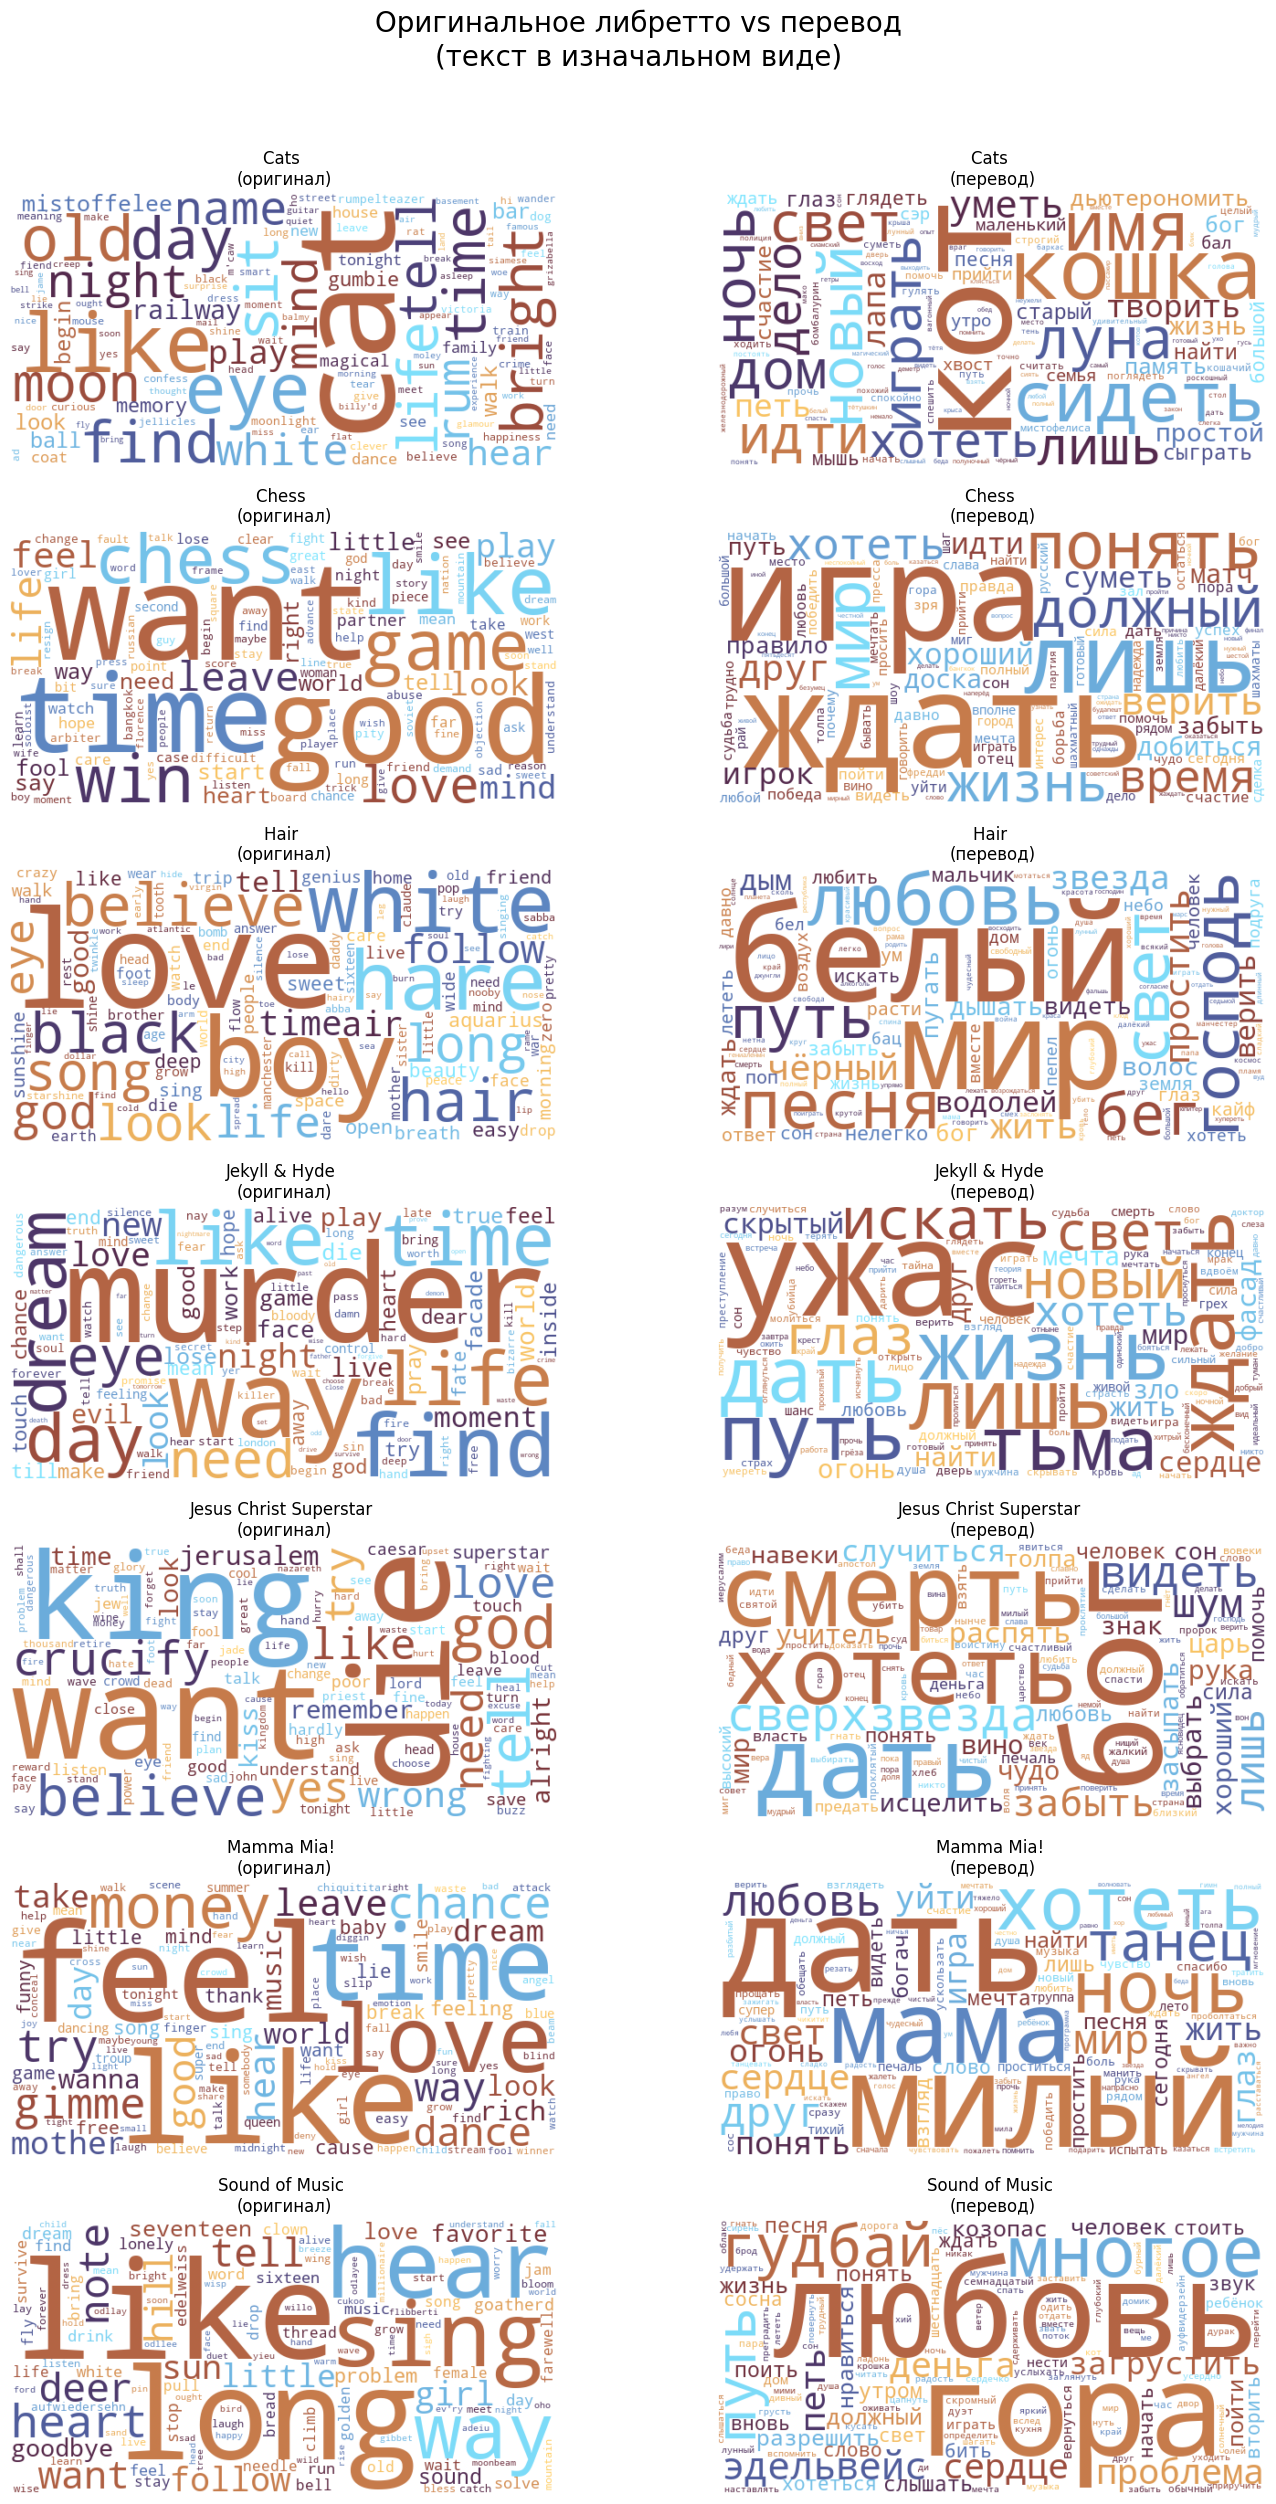

In [66]:
# для удобства пропишем общие для облаков слов параметры отдельно
wc_params = {
    'width': 600,
    'height': 300,
    'background_color': 'white',
    'colormap': 'managua',
    'max_words': 120,
    'collocations': False, # n-граммы
    'normalize_plurals': True,
    'random_state' : 22,
    'max_font_size' : 150
    # 'min_font_size' : 4    
}


# пространство для всех графиков
fig, axes = plt.subplots(nrows=num_musicals, ncols=2, figsize=(15, num_musicals * 3.5))
fig.suptitle('Оригинальное либретто vs перевод\n(текст в изначальном виде)', fontsize=20, y=1.02)

# проходимся по мюзиклам
for idx, musical_name in enumerate(all_musicals):
    
    # слева будет английский, справа русский
    ax_en = axes[idx][0] 
    ax_ru = axes[idx][1] 

    # подготовка данных для каждого мюзикла
    df_musical = wc_long_full[wc_long_full['musical'] == musical_name]
    df_en = df_musical[df_musical['lang'] == 'eng']
    df_ru = df_musical[df_musical['lang'] == 'rus']

    # склеиваем тексты песен мюзикла на каждом из языков в одну сроку
    text_english = ' '.join(df_en['text'].tolist())
    text_russian = ' '.join(df_ru['text'].tolist())

    # облако слов - английский
    wc_params.update(stopwords=stopwords_custom_en)
    wordcloud_en = WordCloud(**wc_params).generate(text_english)
    ax_en.imshow(wordcloud_en, interpolation='bilinear')
    ax_en.set_title(f'{musical_name} \n(оригинал)', fontsize=12)
    ax_en.axis('off')   

    # облако слов - русский
    wc_params.update(stopwords=stopwords_custom_ru)
    wordcloud_ru = WordCloud(**wc_params).generate(text_russian)
    ax_ru.imshow(wordcloud_ru, interpolation='bilinear')
    ax_ru.set_title(f'{musical_name} \n(перевод)', fontsize=12)
    ax_ru.axis('off')
    
    print(f"{musical_name} - облако создано")



plt.tight_layout(h_pad=1.5) 
plt.show()

#### Ключевые слова

In [67]:
# ключевые слова для полных, не обрезанных текстов
# соберем ключевые слова для каждого мюзикла на обоих языках
results = []
all_musicals = wc_long['musical'].unique()
languages = ['eng', 'rus']
corpuses_overall = []

for musical in all_musicals:
    keywords_by_lang = {}
    
    for lang in languages:
        df_subset = wc_long_full[(wc_long_full['musical'] == musical) & (wc_long_full['lang'] == lang)]
        corpus = ' '.join(df_subset['text'].astype(str))
        corpuses_overall.append(corpus) # сохраним на всякий склеенные тексты
        words = corpus.split()
        word_counts = Counter(words)
        top_words = word_counts.most_common(12)
        keywords_by_lang[lang] = ', '.join([word for word, _ in top_words])
    
    results.append({
        'musical': musical,
        'eng_keywords': keywords_by_lang['eng'],
        'rus_keywords': keywords_by_lang['rus']
    })


In [68]:
for res in results:
    print(res['musical'])  
    print(f"\teng: {res['eng_keywords']}")  # Ключевые слова на английском
    print(f"\trus: {res['rus_keywords']}")  # Ключевые слова на русском
    print('\n')

Cats
	eng: cat, like, eye, old, sit, find, time, bright, day, life, tell, moon
	rus: кот, сидеть, имя, новый, ночь, свет, дом, играть, кошка, идти, луна, лишь


Chess
	eng: want, good, like, time, game, chess, win, love, leave, life, feel, play
	rus: игра, ждать, лишь, понять, мир, должный, жизнь, время, хотеть, верить, друг, хороший


Hair
	eng: love, boy, white, hare, believe, hair, black, song, long, look, god, life
	rus: белый, мир, любовь, песня, свет, господь, путь, бег, чёрный, жить, простить, звезда


Jekyll & Hyde
	eng: murder, way, find, like, life, time, dream, day, eye, need, night, look
	rus: ужас, лишь, жизнь, ждать, дать, путь, тьма, искать, новый, глаз, свет, хотеть


Jesus Christ Superstar
	eng: die, want, king, god, tell, believe, crucify, like, yes, love, try, need
	rus: бог, смерть, дать, сверхзвезда, хотеть, лишь, видеть, шум, что-нибудь, забыть, случиться, распять


Mamma Mia!
	eng: feel, like, time, love, money, chance, try, gimme, way, good, dance, hear
	rus: да